In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [2]:
import os

In [3]:
import pandas as pd

file_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(file_path)

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [4]:
print(df.shape)
print(df.info())
print(df.describe())

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

In [5]:
print(df["Class"].value_counts())

fraud_pct = df["Class"].mean() * 100
print("Fraud %:", fraud_pct)

Class
0    284315
1       492
Name: count, dtype: int64
Fraud %: 0.1727485630620034


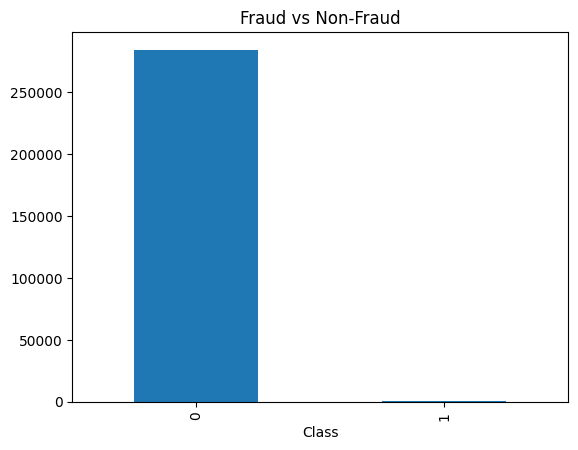

In [6]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud")
plt.show()

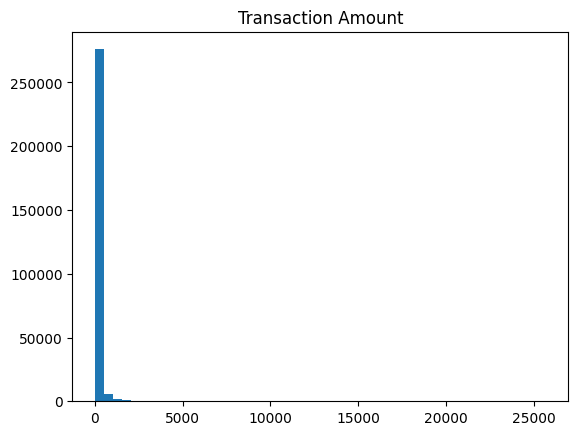

In [7]:
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount")
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])

In [9]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
import numpy as np

df = df.sort_values("Time")

seq_len = 5
X_seq = []
y_seq = []

for i in range(len(df) - seq_len):
    X_seq.append(df.iloc[i:i+seq_len].drop("Class", axis=1).values)
    y_seq.append(df.iloc[i+seq_len]["Class"])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}
print(class_weights)

{0: np.float64(0.5008881580393691), 1: np.float64(281.98143564356434)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model_dense = Sequential([
    Flatten(input_shape=X_train.shape[1:]),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_dense.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_dense = model_dense.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.5492 - loss: 344.2884 - val_accuracy: 0.0022 - val_loss: 293.0972
Epoch 2/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.1737 - loss: 55.0710 - val_accuracy: 0.0021 - val_loss: 0.7232
Epoch 3/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.0234 - loss: 11.3174 - val_accuracy: 0.0028 - val_loss: 0.7170
Epoch 4/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.3264 - loss: 4.8354 - val_accuracy: 0.0018 - val_loss: 0.7005
Epoch 5/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.1880 - loss: 2.0473 - val_accuracy: 0.0016 - val_loss: 0.6945


In [ ]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    LSTM(64, input_shape=X_train.shape[1:]),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - accuracy: 0.8609 - loss: 0.7750 - val_accuracy: 0.9985 - val_loss: 0.5358
Epoch 2/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.6976 - loss: 0.7120 - val_accuracy: 0.9985 - val_loss: 0.6751
Epoch 3/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.6593 - loss: 0.7021 - val_accuracy: 0.0026 - val_loss: 0.7353
Epoch 4/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - accuracy: 0.6822 - loss: 0.7083 - val_accuracy: 0.0049 - val_loss: 0.7461
Epoch 5/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.6237 - loss: 0.7035 - val_accuracy: 0.9984 - val_loss: 0.6736


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, GlobalAveragePooling1D, Attention
from tensorflow.keras.models import Model

inputs = Input(shape=X_train.shape[1:])

x = LSTM(64, return_sequences=True)(inputs)

attention = Attention()([x, x])

x = GlobalAveragePooling1D()(attention)

outputs = Dense(1, activation='sigmoid')(x)

model_attn = Model(inputs, outputs)

model_attn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_attn = model_attn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - accuracy: 0.8273 - loss: 0.8493 - val_accuracy: 0.9985 - val_loss: 0.6577
Epoch 2/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - accuracy: 0.6971 - loss: 0.7091 - val_accuracy: 0.9985 - val_loss: 0.6207
Epoch 3/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - accuracy: 0.6932 - loss: 0.7090 - val_accuracy: 0.9985 - val_loss: 0.5613
Epoch 4/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - accuracy: 0.6008 - loss: 0.7041 - val_accuracy: 0.9985 - val_loss: 0.5414
Epoch 5/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - accuracy: 0.6238 - loss: 0.7044 - val_accuracy: 0.9985 - val_loss: 0.4985


In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, X_test, y_test, name):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))

evaluate_model(model_dense, X_test, y_test, "Dense Model")
evaluate_model(model_lstm, X_test, y_test, "LSTM Model")
evaluate_model(model_attn, X_test, y_test, "LSTM + Attention Model")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

Dense Model Results:
              precision    recall  f1-score   support

         0.0       1.00      0.00      0.00     56873
         1.0       0.00      1.00      0.00        88

    accuracy                           0.00     56961
   macro avg       0.50      0.50      0.00     56961
weighted avg       1.00      0.00      0.00     56961

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

LSTM Model Results:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56873
         1.0       0.00      0.00      0.00        88

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step

LSTM + Attention Model Results:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56873
         1.0       0.00      0.0

c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

In [ ]:
def get_metrics(model, X_test, y_test):
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    return (
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    )

dense_metrics = get_metrics(model_dense, X_test, y_test)
lstm_metrics = get_metrics(model_lstm, X_test, y_test)
attn_metrics = get_metrics(model_attn, X_test, y_test)

print("+----------------------+-----------+-----------+-----------+")
print("| Model                | Precision | Recall    | F1 Score  |")
print("+----------------------+-----------+-----------+-----------+")
print(f"| Dense                | {dense_metrics[0]:.4f}   | {dense_metrics[1]:.4f}   | {dense_metrics[2]:.4f}   |")
print(f"| LSTM                 | {lstm_metrics[0]:.4f}   | {lstm_metrics[1]:.4f}   | {lstm_metrics[2]:.4f}   |")
print(f"| LSTM + Attention     | {attn_metrics[0]:.4f}   | {attn_metrics[1]:.4f}   | {attn_metrics[2]:.4f}   |")
print("+----------------------+-----------+-----------+-----------+")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
+----------------------+-----------+-----------+-----------+
| Model                | Precision | Recall    | F1 Score  |
+----------------------+-----------+-----------+-----------+
| Dense                | 0.0015   | 1.0000   | 0.0031   |
| LSTM                 | 0.0000   | 0.0000   | 0.0000   |
| LSTM + Attention     | 0.0000   | 0.0000   | 0.0000   |
+----------------------+-----------+-----------+-----------+


c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import tensorflow as tf

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    
    angle_rates = 1 / np.power(10000, (2*(i//2))/d_model)
    angle_rads = pos * angle_rates
    
    PE = np.zeros((seq_len, d_model))
    PE[:, 0::2] = np.sin(angle_rads[:, 0::2])
    PE[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
    return tf.cast(PE, dtype=tf.float32)

In [ ]:
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling1D
from tensorflow.keras.models import Model

class PositionalEncodingLayer(tf.keras.layers.Layer):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_encoding = positional_encoding(seq_len, d_model)

    def call(self, x):
        return x + self.pos_encoding

# Input
inputs = Input(shape=X_train.shape[1:])

# Project features to embedding space
x = Dense(64)(inputs)

# Add positional encoding
x = PositionalEncodingLayer(seq_len=X_train.shape[1], d_model=64)(x)

# LSTM
x = LSTM(64, return_sequences=True)(x)

# Attention
attention = tf.keras.layers.Attention()([x, x])

# Pooling
x = GlobalAveragePooling1D()(attention)

# Output
outputs = Dense(1, activation='sigmoid')(x)

model_pe = Model(inputs, outputs)

model_pe.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_pe.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 5, 30)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5, 64)     │      1,984 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 5, 64)     │          0 │ dense_5[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 5, 64)     │     33,024 │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 5, 64)     │          0 │ lstm_2[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ attention_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,073 (137.00 KB)

 Trainable params: 35,073 (137.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_pe = model_pe.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - accuracy: 0.7663 - loss: 0.8304 - val_accuracy: 0.9984 - val_loss: 0.6789
Epoch 2/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 58s 8ms/step - accuracy: 0.6137 - loss: 0.7082 - val_accuracy: 0.9984 - val_loss: 0.6603
Epoch 3/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 57s 8ms/step - accuracy: 0.6598 - loss: 0.7062 - val_accuracy: 0.9985 - val_loss: 0.6272
Epoch 4/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - accuracy: 0.5847 - loss: 0.7025 - val_accuracy: 0.9985 - val_loss: 0.5826
Epoch 5/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 56s 8ms/step - accuracy: 0.5601 - loss: 0.7031 - val_accuracy: 0.9985 - val_loss: 0.6665


In [ ]:
from sklearn.metrics import classification_report

y_pred_pe = (model_pe.predict(X_test) > 0.5).astype(int)

print("LSTM + Attention + Positional Encoding")
print(classification_report(y_test, y_pred_pe))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
LSTM + Attention + Positional Encoding
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56873
         1.0       0.00      0.00      0.00        88

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961



c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

In [ ]:
pe_metrics = get_metrics(model_pe, X_test, y_test)

print("+------------------------------+-----------+-----------+-----------+")
print("| Model                        | Precision | Recall    | F1 Score  |")
print("+------------------------------+-----------+-----------+-----------+")
print(f"| Dense                        | {dense_metrics[0]:.4f}   | {dense_metrics[1]:.4f}   | {dense_metrics[2]:.4f}   |")
print(f"| LSTM                         | {lstm_metrics[0]:.4f}   | {lstm_metrics[1]:.4f}   | {lstm_metrics[2]:.4f}   |")
print(f"| LSTM + Attention             | {attn_metrics[0]:.4f}   | {attn_metrics[1]:.4f}   | {attn_metrics[2]:.4f}   |")
print(f"| LSTM + Attention + PE        | {pe_metrics[0]:.4f}   | {pe_metrics[1]:.4f}   | {pe_metrics[2]:.4f}   |")
print("+------------------------------+-----------+-----------+-----------+")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
+------------------------------+-----------+-----------+-----------+
| Model                        | Precision | Recall    | F1 Score  |
+------------------------------+-----------+-----------+-----------+
| Dense                        | 0.0015   | 1.0000   | 0.0031   |
| LSTM                         | 0.0000   | 0.0000   | 0.0000   |
| LSTM + Attention             | 0.0000   | 0.0000   | 0.0000   |
| LSTM + Attention + PE        | 0.0000   | 0.0000   | 0.0000   |
+------------------------------+-----------+-----------+-----------+


c:\Users\Nishath Tabassum\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model

class AttentionWithScores(tf.keras.layers.Layer):
    def call(self, inputs):
        query, value = inputs
        scores = tf.matmul(query, value, transpose_b=True)
        weights = tf.nn.softmax(scores, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

In [ ]:
inputs = Input(shape=X_train.shape[1:])

x = Dense(64)(inputs)
x = LSTM(64, return_sequences=True)(x)

attn_layer = AttentionWithScores()
attn_output, attn_scores = attn_layer([x, x])

x = tf.keras.layers.GlobalAveragePooling1D()(attn_output)
outputs = Dense(1, activation='sigmoid')(x)

model_explain = Model(inputs, outputs)

model_explain.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model_explain.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 63s 8ms/step - accuracy: 0.8475 - loss: 0.8401 - val_accuracy: 0.0015 - val_loss: 0.8917
Epoch 2/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 61s 8ms/step - accuracy: 0.5813 - loss: 0.7029 - val_accuracy: 0.9985 - val_loss: 0.6447
Epoch 3/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - accuracy: 0.6101 - loss: 0.7089 - val_accuracy: 0.0016 - val_loss: 0.7863
Epoch 4/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - accuracy: 0.5317 - loss: 0.7018 - val_accuracy: 0.9985 - val_loss: 0.5629
Epoch 5/5
7121/7121 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - accuracy: 0.6396 - loss: 0.6999 - val_accuracy: 0.9985 - val_loss: 0.6014


In [ ]:
attention_model = Model(inputs=model_explain.input, outputs=attn_scores)

In [ ]:
sample = X_test[0:1]

scores = attention_model.predict(sample)

print("Attention shape:", scores.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
Attention shape: (1, 5, 5)


In [ ]:
import numpy as np

importance = np.mean(scores[0], axis=0)

print("Transaction Importance:", importance)
print("Most important index:", np.argmax(importance))

Transaction Importance: [0.01251003 0.17305937 0.2606581  0.27582377 0.27794874]
Most important index: 4


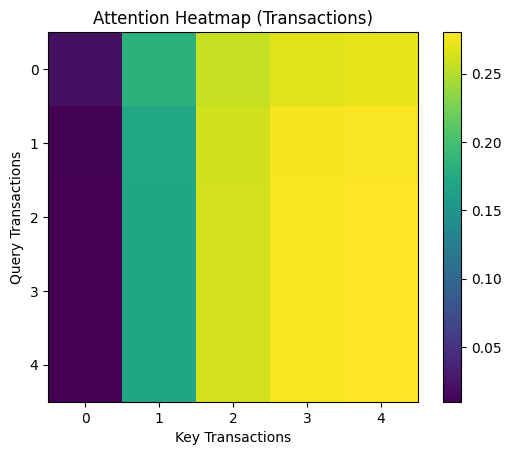

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(scores[0], cmap='viridis')
plt.colorbar()
plt.title("Attention Heatmap (Transactions)")
plt.xlabel("Key Transactions")
plt.ylabel("Query Transactions")
plt.show()

In [ ]:
important_idx = np.argmax(importance)

print("Most important transaction position:", important_idx)
print("Transaction data:", sample[0][important_idx])

Most important transaction position: 4
Transaction data: [ 1.15968000e+05 -7.56232195e-01  1.01563186e-01  9.14329281e-01
 -2.27058300e+00 -3.69296455e-01 -2.62632332e-01 -3.25769232e-01
  4.73892784e-01 -9.88551490e-01 -5.39491844e-01 -1.26910928e+00
 -5.95184181e-01  4.94271885e-01 -3.72727304e-01 -5.21825282e-01
  1.43829449e+00 -1.69384191e-03 -1.06091264e+00 -2.09638723e-01
  2.11691250e-03  4.46125313e-01  1.04011906e+00 -1.95574909e-01
  6.42536201e-01  3.96140830e-02 -2.07086275e-01 -9.13498567e-03
  5.46990049e-02 -2.53317219e-01]


In [ ]:
model_pe.save("fraud_model.keras") 